In [21]:
import csv
from datetime import datetime, timedelta
import random

# Function to generate a random date within the year
def random_date(start_date, end_date):
    return start_date + timedelta(
        seconds=random.randint(0, int((end_date - start_date).total_seconds()))
    )

# Set the start and end date for the year
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 12, 31)

# Open a CSV file for writing
with open('manufacturing_data_large.csv', 'w', newline='') as csvfile:
    fieldnames = ['Production Date', 'Production Line', 'Equipment Efficiency',
                  'Quality Control Metric', 'Production Speed', 'Defects',
                  'Maintenance Hours', 'Worker Productivity']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    # Write the header
    writer.writeheader()

    # Generate and write 300 lines of fictional data
    for _ in range(300):
        writer.writerow({
            'Production Date': random_date(start_date, end_date).strftime('%Y-%m-%d'),
            'Production Line': random.choice(['Line A', 'Line B']),
            'Equipment Efficiency': f"{random.uniform(85, 95):.2f}%",
            'Quality Control Metric': f"{random.uniform(0.85, 0.95):.2f}",
            'Production Speed': f"{random.randint(90, 120)} units/hour",
            'Defects': random.randint(0, 8),
            'Maintenance Hours': random.randint(2, 8),
            'Worker Productivity': f"{random.uniform(75, 90):.2f}%"
        })

print("CSV file 'manufacturing_data_large.csv' has been generated with 300 lines of fictional data.")


CSV file 'manufacturing_data_large.csv' has been generated with 300 lines of fictional data.


In [22]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd 
df = pd.read_csv("manufacturing_data_large.csv")

print("original DataFrame: ")
print(df.head())


original DataFrame: 
  Production Date Production Line Equipment Efficiency  \
0      2023-05-04          Line A               85.89%   
1      2023-11-13          Line B               90.53%   
2      2023-06-17          Line B               89.49%   
3      2023-04-10          Line A               86.12%   
4      2023-06-03          Line A               92.45%   

   Quality Control Metric Production Speed  Defects  Maintenance Hours  \
0                    0.87    96 units/hour        5                  8   
1                    0.89    99 units/hour        1                  6   
2                    0.89   101 units/hour        7                  3   
3                    0.86   115 units/hour        0                  2   
4                    0.93   102 units/hour        6                  4   

  Worker Productivity  
0              88.17%  
1              77.04%  
2              83.36%  
3              82.62%  
4              83.72%  


In [24]:
print("\nMissing values: ")
print(df.isnull().sum())


Missing values: 
Production Date           0
Production Line           0
Equipment Efficiency      0
Quality Control Metric    0
Production Speed          0
Defects                   0
Maintenance Hours         0
Worker Productivity       0
dtype: int64


In [25]:
df.drop_duplicates(inplace=True)

In [26]:
df['Production Date'] = pd.to_datetime(df['Production Date'])

df['Equipment Efficiency'] = df['Equipment Efficiency'].str.rstrip('%').astype('float')/ 100.0
df['Worker Productivity'] = df['Worker Productivity'].str.rstrip('%').astype('float')/ 100.0

In [27]:
print("\nCleaned Data: ")
print(df.head())
df.to_csv('cleaned_manufacturing_data.csv', index=False)

print("\nCleaned data saved to 'cleaned_manufacturing_data.csv'")


Cleaned Data: 
  Production Date Production Line  Equipment Efficiency  \
0      2023-05-04          Line A                0.8589   
1      2023-11-13          Line B                0.9053   
2      2023-06-17          Line B                0.8949   
3      2023-04-10          Line A                0.8612   
4      2023-06-03          Line A                0.9245   

   Quality Control Metric Production Speed  Defects  Maintenance Hours  \
0                    0.87    96 units/hour        5                  8   
1                    0.89    99 units/hour        1                  6   
2                    0.89   101 units/hour        7                  3   
3                    0.86   115 units/hour        0                  2   
4                    0.93   102 units/hour        6                  4   

   Worker Productivity  
0               0.8817  
1               0.7704  
2               0.8336  
3               0.8262  
4               0.8372  

Cleaned data saved to 'cleaned_ma

In [28]:
pip install matplotlib


[notice] A new release of pip is available: 23.1.2 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("cleaned_manufacturing_data.csv")

In [31]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Production Date         300 non-null    object 
 1   Production Line         300 non-null    object 
 2   Equipment Efficiency    300 non-null    float64
 3   Quality Control Metric  300 non-null    float64
 4   Production Speed        300 non-null    object 
 5   Defects                 300 non-null    int64  
 6   Maintenance Hours       300 non-null    int64  
 7   Worker Productivity     300 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 18.9+ KB
None
       Equipment Efficiency  Quality Control Metric     Defects  \
count            300.000000              300.000000  300.000000   
mean               0.901907                0.899267    4.083333   
std                0.028789                0.028860    2.532014   
min                0.850100   

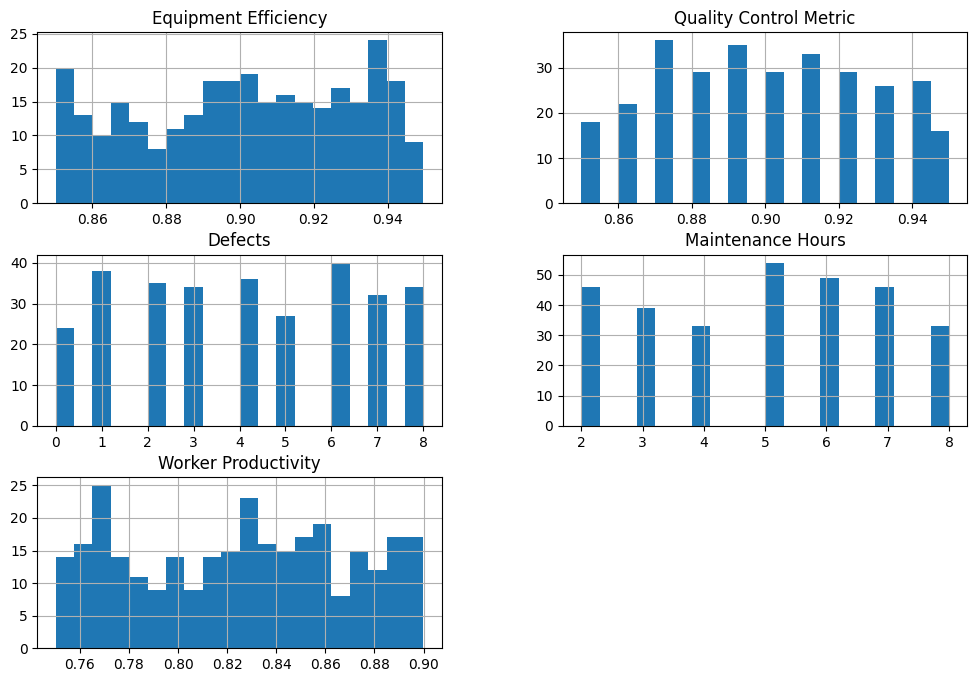

In [32]:
df.hist(figsize =(12, 8) , bins=20)
plt.show()

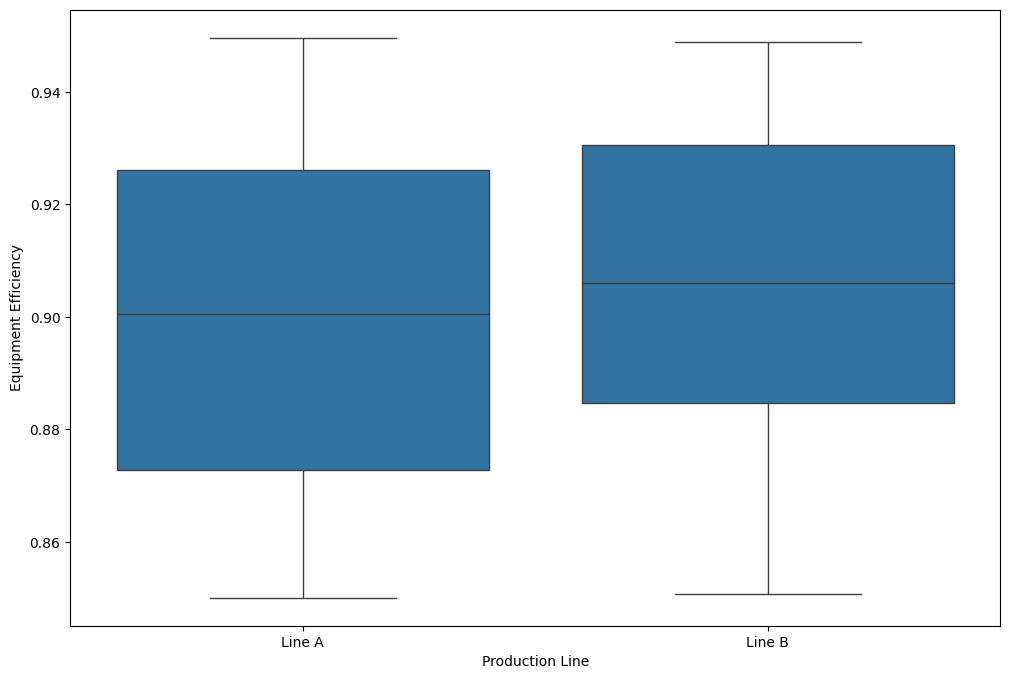

In [33]:
plt.figure(figsize=(12, 8))
sns.boxplot(x="Production Line", y='Equipment Efficiency' , data=df)
plt.show()


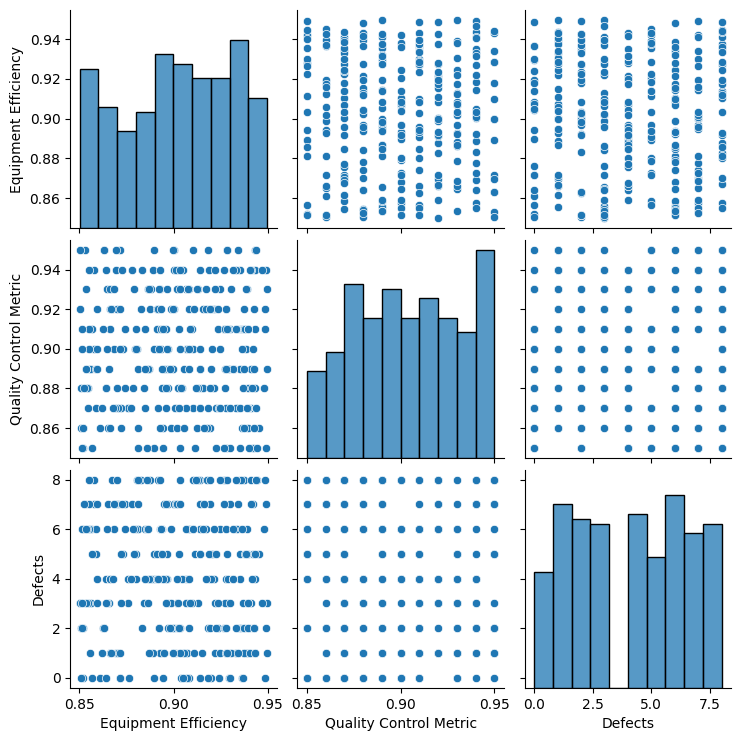

In [34]:
sns.pairplot(df[['Equipment Efficiency', 'Quality Control Metric', 'Production Speed' , 'Defects']])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

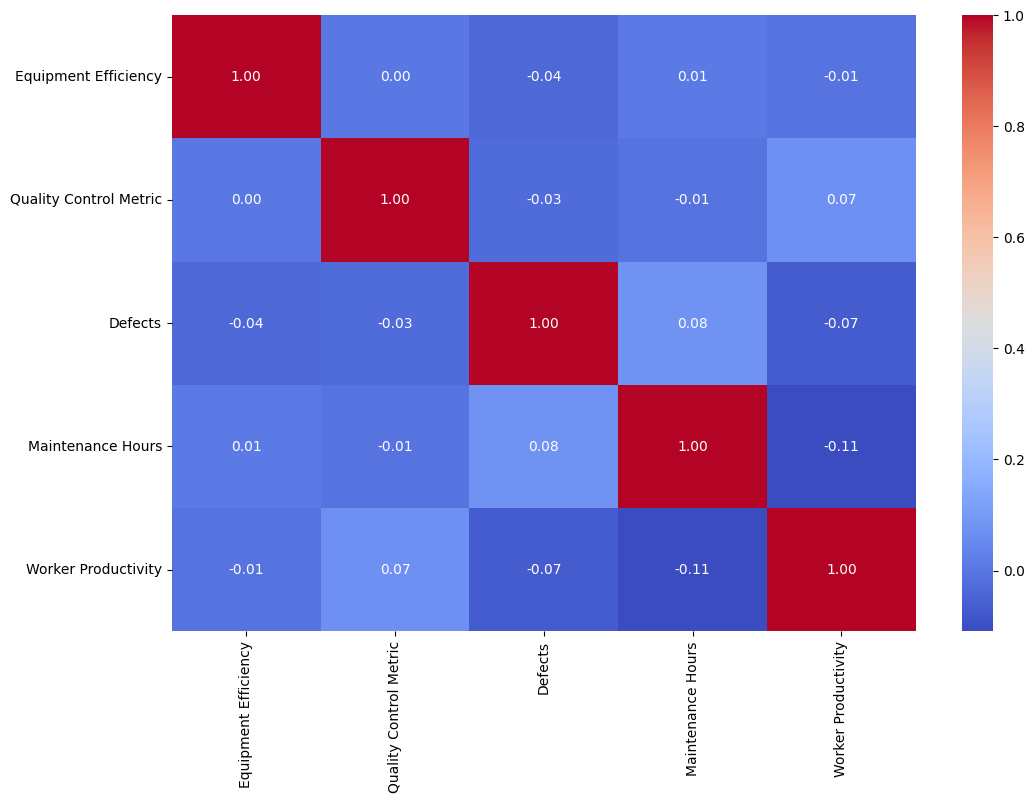

In [35]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
                                           
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show

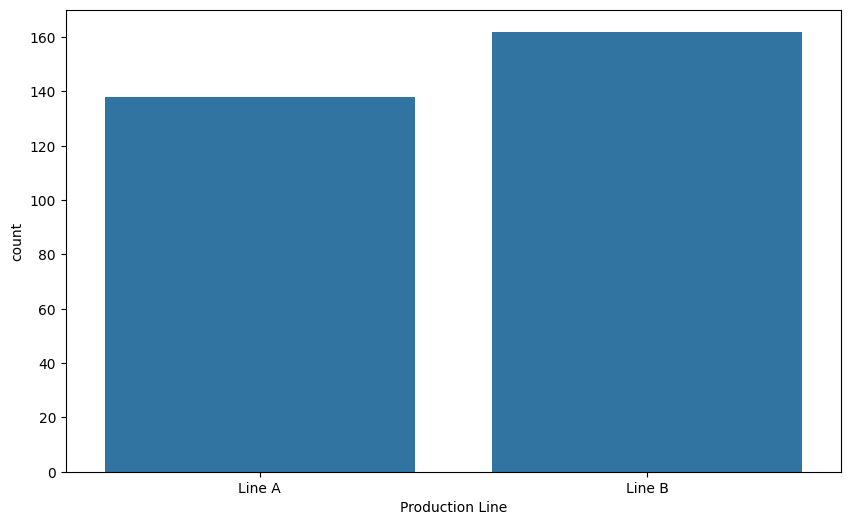

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Production Line', data=df)
plt.show()


In [44]:
print(df.columns)


Index(['Production Line', 'Equipment Efficiency', 'Quality Control Metric',
       'Production Speed', 'Defects', 'Maintenance Hours',
       'Worker Productivity'],
      dtype='object')


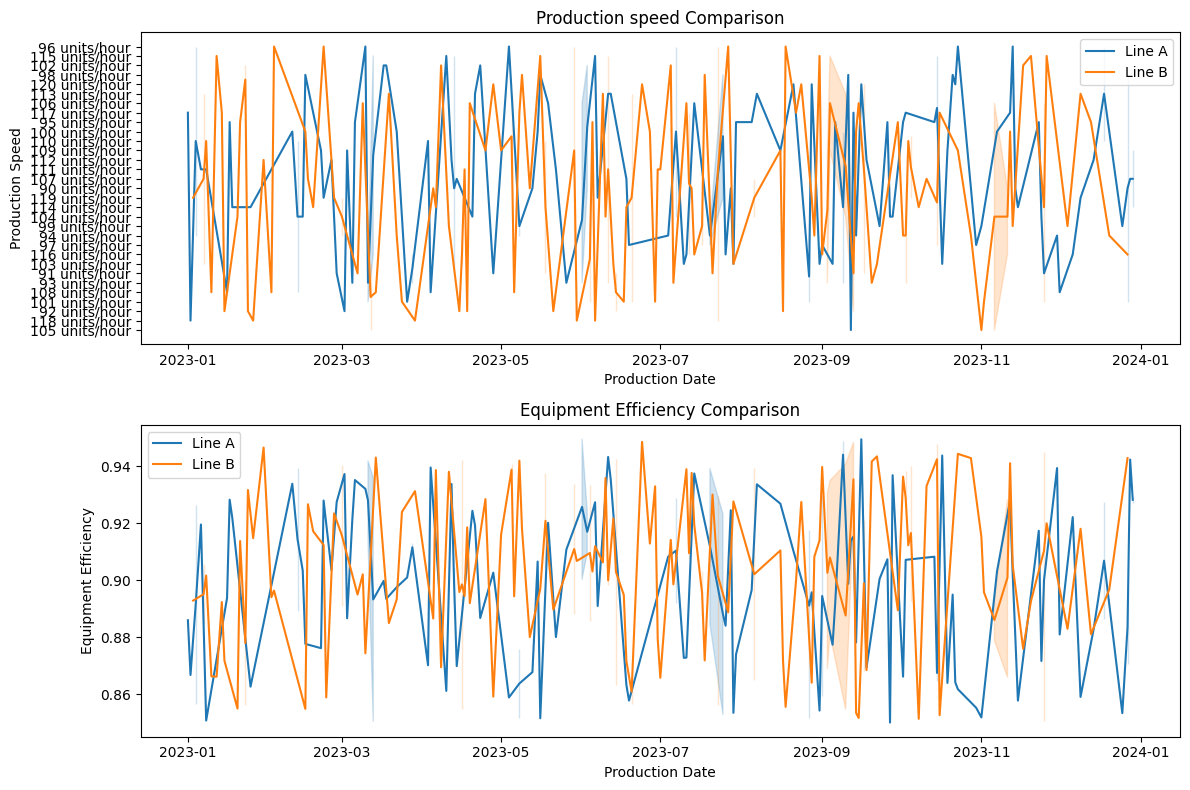

In [47]:
line_a_data = df[df['Production Line'] == 'Line A']
line_b_data = df[df['Production Line'] == 'Line B']

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
sns.lineplot(x='Production Date', y='Production Speed', data=line_a_data, label='Line A')
sns.lineplot(x='Production Date', y='Production Speed', data=line_b_data, label='Line B')
plt.title('Production speed Comparison')
plt.legend()

plt.subplot(2, 1, 2)
sns.lineplot(x='Production Date', y='Equipment Efficiency', data=line_a_data, label='Line A')
sns.lineplot(x='Production Date', y='Equipment Efficiency', data=line_b_data, label='Line B')
plt.title('Equipment Efficiency Comparison')
plt.legend()

plt.tight_layout()

plt.show()